# Vorhersage des Finanzierungserfolgs von Kickstarter-Kampagnen aus dem Kampagnentext

Schriftliche Ausarbeitung im Modul Natural Language Processing, Sommersemester 2026

Fachhochschule Südwestfalen, Masterstudiengang Angewandte Künstliche Intelligenz

Dozent Prof. Dr. Christian Gawron

Yurii Dobrytsia, Matrikelnummer 30518764

28.09.2026

## Zusammenfassung

Diese Arbeit prüft, wie gut der Kurztext einer Kickstarter-Kampagne ihren Finanzierungserfolg vorhersagt und ob diese Vorhersage für spätere Jahrgänge stabil bleibt. Grundlage ist ein öffentlicher Abzug von webrobots.io mit 115.809 beendeten Kampagnen aus englischsprachigen Ländern. Die Modelle werden mit Kampagnen bis 2019 trainiert, die Regularisierung wird auf 2020 gewählt, und getestet wird auf 2021 bis 2025. Titel und Kurztext erreichen mit TF-IDF und logistischer Regression einen Makro-F1 von 0,595, genauso viel wie ein Modell mit Finanzierungsziel und Kategorie. Zusammen kommen beide auf 0,643, die Mehrheitsklasse auf 0,42. Über die Testjahre verliert das Textmodell weniger als das Metadatenmodell, bei nur 5 Testjahren ist das aber eine Tendenz. Die stärksten Wörter stehen vor allem für die Art des Projekts. Der Kurztext ist damit ein brauchbares, aber schwaches Signal.

## Inhaltsverzeichnis

- Zusammenfassung
- 1 Problemstellung und Daten
- 2 Stand der Technik
- 3 Lösung und Evaluation
- 4 Kritische Reflexion und Fazit
- Literaturverzeichnis
- Erklärung

## 1 Problemstellung und Daten

### 1.1 Problem und Forschungsfrage

Auf Kickstarter werben Gründerinnen, Kunstschaffende und kleine Firmen öffentlich um Geld für ein Vorhaben. Es gilt das Alles-oder-nichts-Prinzip. Das Geld fließt nur, wenn die Kampagne ihr Finanzierungsziel bis zum Enddatum erreicht (Mitra und Gilbert, 2014). Wer eine Kampagne plant, würde die Erfolgschance deshalb gern schon vor dem Start kennen.

Beim Start stehen vor allem das Ziel in Dollar, die Kategorie, der Titel und ein Kurztext fest, der auf den Übersichtsseiten erscheint. Mich interessiert, wie viel dieser kurze Text über die Erfolgschance verrät, wenn Ziel und Kategorie schon bekannt sind. Außerdem verändern sich Plattform und Publikum über die Jahre. Ein Modell, das auf alten Kampagnen gelernt hat, muss auch auf neuen funktionieren, sonst nützt es in der Praxis wenig.

**Wie gut sagt der Kurztext einer Kickstarter-Kampagne voraus, ob sie ihr Finanzierungsziel erreicht, verglichen mit einem Modell, das nur Finanzierungsziel und Kategorie kennt, und bleibt diese Vorhersage für spätere Jahrgänge stabil?**

Ich beantworte die Frage mit einer zeitlichen Aufteilung. Die Modelle werden mit Kampagnen bis 2019 trainiert, die Regularisierung wird auf 2020 gewählt, und getestet wird auf 2021 bis 2025.

### 1.2 Daten

Die Daten stammen aus dem öffentlichen Kickstarter-Abzug von webrobots.io vom 10.09.2026 (webrobots.io, 2026). Webrobots liest regelmäßig die Übersichtsseiten von Kickstarter aus und speichert je Kampagne unter anderem Titel, Kurztext, Ziel, Währung, Kategorie, Land, Startzeit und Status. Der Abzug ist keine Vollerhebung. Er enthält nur Kampagnen, die beim Auslesen auf diesen Übersichtsseiten erschienen, und dieselbe Kampagne kann auf mehreren Seiten stehen.

Das Skript `prepare_data.py` behält nur beendete Kampagnen mit dem Status successful oder failed, entfernt Dubletten nach der Kampagnen-ID und beschränkt die Daten auf sechs englischsprachige Länder. Das Ziel wird in US-Dollar umgerechnet.

In [1]:
%%capture
%pip install pandas==3.0.6 numpy==2.4.6 scipy==1.17.1 scikit-learn==1.9.1 matplotlib==3.11.2
%pip install torch==2.14.0 transformers==4.57.6 sentence-transformers==5.7.0

In [2]:
import json, time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, scipy.sparse as sp, torch
from threadpoolctl import threadpool_limits
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
RANDOM_STATE = 1977  # fester Seed für Stichprobe und Modelle
DATA = Path('data')
torch.set_num_threads(2); threadpool_limits(2)  # feste Zahl an Threads für vergleichbare Laufzeiten
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv(DATA / 'kickstarter_filtered.csv.gz')
print('Protokoll von prepare_data.py:', json.loads((DATA / 'prepare_log.json').read_text()))
df['text'] = df['name'].fillna('') + '. ' + df['blurb'].fillna('')  # Titel und Kurztext
df['log_goal'] = np.log10(df['goal_usd'])
df['teil'] = pd.cut(df['launched_year'], [2000, 2019, 2020, 2025, 2030],
                    labels=['train', 'dev', 'test', 'ausgelassen'])
print(f'{len(df):,} Kampagnen, Startjahre {df.launched_year.min()} bis {df.launched_year.max()}, '
      f'Anteil erfolgreich {df.success.mean():.3f}')
print('Länder:', df['country'].value_counts().to_dict())
print(f"Kurztext höchstens {df['blurb'].str.len().max():.0f} Zeichen, Wörter je Text im Median "
      f"{df['text'].str.split().str.len().median():.0f}, Ziel im Median {df['goal_usd'].median():,.0f} USD")
df[['launched_year', 'main_cat', 'goal_usd', 'success', 'text']].head(3)

Protokoll von prepare_data.py: {'CSV-Dateien': 63, 'Zeilen roh': 194160, 'eindeutige ids': 157331, 'successful/failed, dedupliziert': 138189, 'englischsprachige Länder': 115809}
115,809 Kampagnen, Startjahre 2009 bis 2026, Anteil erfolgreich 0.676
Länder: {'US': 88596, 'GB': 16543, 'CA': 6294, 'AU': 3245, 'NZ': 601, 'IE': 530}


Kurztext höchstens 150 Zeichen, Wörter je Text im Median 24, Ziel im Median 4,000 USD


,launched_year,main_cat,goal_usd,success,text
0,2009,Technology,99.0,1,Offline Wikipedia iPhone app. This is a project to create a free iPhone app for browsing Wikipedia offline. The code will be open source and I'll launch it with...
1,2009,Journalism,3000.0,1,New York Makes a Book!!. Let's make the world's first crowd-funded book! \r\n\r\nNew York Makes a Book will be entirely composed of submissions from 100 participants. 100...
2,2009,Games,1500.0,1,"Crossword Puzzles!. I create crosswords and other puzzles. These have appeared, among other places, in The New York Times, The Wall Street Journal, and Games Magazine..."


Aus 194.160 Rohzeilen mit 157.331 verschiedenen IDs bleiben nach Statusfilter und Deduplizierung 138.189 Kampagnen, nach dem Länderfilter 115.809. Davon stammen 88.596 aus den USA und 16.543 aus Großbritannien. Insgesamt sind 67,6 % der Kampagnen erfolgreich. Titel und Kurztext haben zusammen im Median 24 Wörter, der Kurztext selbst ist höchstens 150 Zeichen lang. Das Ziel liegt im Median bei 4.000 US-Dollar.

launched_year   2009   2010   2011   2012  2013   2014   2015  2016  2017   2018   2019   2020   2021  \
Kampagnen        119    665   1911   3721  3999  10395  12304  8476  7775   6742   6153   4576   4961   
Erfolgsquote   0.941  0.928  0.876  0.885  0.86  0.556  0.495  0.56   0.6  0.656  0.683  0.703  0.765   

launched_year   2022   2023   2024   2025   2026  
Kampagnen       5507   5955  10361  12637   9552  
Erfolgsquote   0.735  0.747  0.715  0.703  0.783  


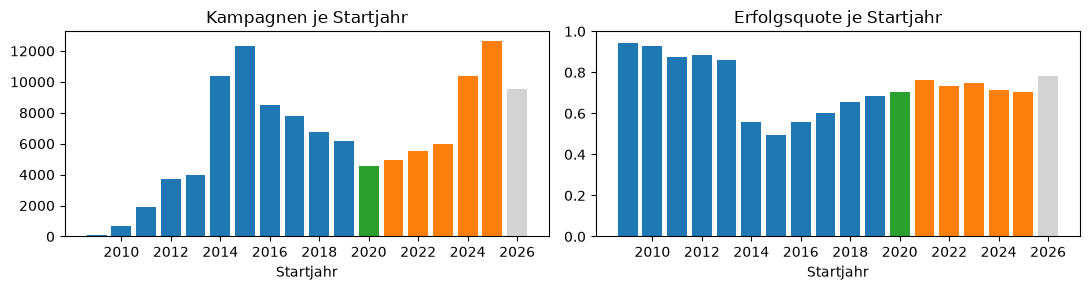

In [4]:
years = df.groupby('launched_year').agg(Kampagnen=('success', 'size'), Erfolgsquote=('success', 'mean'))
print(years.round(3).astype(object).T.to_string(line_width=105))
colors = df.groupby('launched_year')['teil'].first().map(
    {'train': 'tab:blue', 'dev': 'tab:green', 'test': 'tab:orange', 'ausgelassen': 'lightgrey'})
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, col in zip(axes, ['Kampagnen', 'Erfolgsquote']):
    ax.bar(years.index, years[col], color=colors)
    ax.set(title=col + ' je Startjahr', xlabel='Startjahr', xticks=range(2010, 2027, 2))
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Abbildung 1:** Anzahl der Kampagnen (links) und Anteil erfolgreicher Kampagnen (rechts) je Startjahr. Blau ist train, grün dev, orange test, grau nicht verwendet.

Nach wenigen Kampagnen in den ersten Jahren springt die Zahl 2014 auf 10.395 und 2015 auf 12.304, fällt bis 2020 auf 4.576 und steigt bis 2025 wieder auf 12.637. Auffällig ist die Erfolgsquote. Von 2009 bis 2013 liegt sie zwischen 0,86 und 0,941, von 2014 bis 2025 zwischen 0,495 und 0,765. Für die frühen Jahre berichtet die Literatur deutlich niedrigere Quoten, 51,53 % bei Mitra und Gilbert (2014) für Projekte bis Juni 2012 und 48,24 % bei Etter et al. (2013) für September 2012 bis Mai 2013. Der Abzug enthält für die frühen Jahre also vor allem erfolgreiche Kampagnen. Ich vermute, dass die Übersichtsseiten ältere gescheiterte Kampagnen seltener zeigen, prüfen lässt sich das mit diesen Daten nicht.

Für die Aufteilung nehme ich train bis 2019, dev 2020 und test 2021 bis 2025. Das Jahr 2026 lasse ich weg, weil es beim Abzug noch nicht abgeschlossen war und nur die bis dahin beendeten Kampagnen enthält.

In [5]:
train, dev, test = (df[df['teil'] == t].reset_index(drop=True) for t in ['train', 'dev', 'test'])
y_train, y_dev, y_test = train['success'].values, dev['success'].values, test['success'].values
splits = {'train': train, 'dev': dev, 'test': test}
pd.DataFrame({n: {'Jahre': f'{d.launched_year.min()} bis {d.launched_year.max()}', 'Kampagnen': len(d),
                  'erfolgreich': d.success.sum(), 'gescheitert': len(d) - d.success.sum(),
                  'Anteil erfolgreich': round(d.success.mean(), 3)} for n, d in splits.items()}).T

,Jahre,Kampagnen,erfolgreich,gescheitert,Anteil erfolgreich
train,2009 bis 2019,62260,39043,23217,0.627
dev,2020 bis 2020,4576,3216,1360,0.703
test,2021 bis 2025,39421,28586,10835,0.725


Train umfasst 62.260 Kampagnen, dev 4.576 und test 39.421. Der Anteil erfolgreicher Kampagnen steigt von 0,627 in train über 0,703 in dev auf 0,725 in test. Die Modelle werden also auf einer anderen Klassenverteilung geprüft, als sie gelernt haben.

## 2 Stand der Technik

Mit der Vorhersage des Erfolgs von Crowdfunding-Kampagnen befassen sich Arbeiten seit etwa 2013. Greenberg et al. (2013) sagten den Erfolg von Kickstarter-Kampagnen allein aus Merkmalen vorher, die schon beim Start feststehen, etwa Kategorie, Ziel und ob es ein Video gibt. Etter et al. (2013) nutzten dagegen den Verlauf der Kampagne. Ihre Modelle beobachten die Zeitreihe der zugesagten Beträge sowie Tweets und den Graphen zwischen Projekten und Unterstützern. Solche Modelle sind stark, setzen aber voraus, dass die Kampagne schon läuft.

Mitra und Gilbert (2014) untersuchten gezielt die Sprache der Kampagnen. Sie zerlegten die vollständigen Projektbeschreibungen in Phrasen und nahmen diese zusammen mit Kontrollvariablen wie Dauer und Video in eine penalisierte logistische Regression auf. Die Phrasen senkten die Fehlerrate stark, und viele der stärksten Phrasen lassen sich Prinzipien der Überzeugung wie der Gegenseitigkeit zuordnen, etwa Belohnungen für Unterstützer. Neuere Arbeiten verwenden vortrainierte Sprachmodelle. Gunduz und Alatas (2024) klassifizierten nur die Kurztexte, mit Merkmalen aus BERT (Bidirectional Encoder Representations from Transformers) und FastText und den Klassifikatoren LSTM (Long Short-Term Memory) und Gradient Boosting. Die folgende Tabelle fasst die Kennzahlen aus den Originalarbeiten zusammen.

In [6]:
pd.DataFrame([
    ['Mitra & Gilbert (2014)', '45,810 Projekte bis Juni 2012, 51.53 % erfolgreich',
     'Phrasen der Projektbeschreibung und 59 Kontrollvariablen, penalisierte LR, 10-fache CV',
     'Fehlerrate 17.03 % nur Kontrollvariablen, 2.4 % mit Phrasen'],
    ['Etter et al. (2013)', '16,042 Kampagnen, 09/2012 bis 05/2013, 48.24 % erfolgreich',
     'Zeitreihe der Zusagen, Twitter und Unterstützergraph, kNN und Markov-Modell',
     'Accuracy über 76 % 4 h nach Start, über 85 % nach 15 % der Laufzeit'],
    ['Gunduz & Alatas (2024)', 'etwa 191,724 Kampagnen (Datensatz von 2018), nur Kurztext',
     'feinabgestimmtes BERT und LSTM, zufällige Aufteilung 80/20',
     'Accuracy 0.745, F1 gescheitert 0.636, F1 erfolgreich 0.803']],
    columns=['Quelle', 'Daten', 'Methode', 'Ergebnis'])

,Quelle,Daten,Methode,Ergebnis
0,Mitra & Gilbert (2014),"45,810 Projekte bis Juni 2012, 51.53 % erfolgreich","Phrasen der Projektbeschreibung und 59 Kontrollvariablen, penalisierte LR, 10-fache CV","Fehlerrate 17.03 % nur Kontrollvariablen, 2.4 % mit Phrasen"
1,Etter et al. (2013),"16,042 Kampagnen, 09/2012 bis 05/2013, 48.24 % erfolgreich","Zeitreihe der Zusagen, Twitter und Unterstützergraph, kNN und Markov-Modell","Accuracy über 76 % 4 h nach Start, über 85 % nach 15 % der Laufzeit"
2,Gunduz & Alatas (2024),"etwa 191,724 Kampagnen (Datensatz von 2018), nur Kurztext","feinabgestimmtes BERT und LSTM, zufällige Aufteilung 80/20","Accuracy 0.745, F1 gescheitert 0.636, F1 erfolgreich 0.803"


Die Zahlen sind mit dieser Arbeit nur eingeschränkt vergleichbar. Alle 3 Studien teilen ihre Daten zufällig oder per Kreuzvalidierung auf, Training und Test stammen also aus derselben Zeit. Mitra und Gilbert (2014) lasen die vollständigen Projektseiten erst aus, als die meisten Kampagnen bereits beendet waren, und nutzen neben dem Text viele weitere Merkmale, darunter die Zahl der Kommentare und Updates, die erst während der Kampagne entstehen. Mitra und Gilbert (2014) sowie Etter et al. (2013) berichten nur Fehlerrate oder Accuracy, Gunduz und Alatas (2024) zusätzlich F1 je Klasse, aber keinen Makro-F1. Am nächsten an dieser Arbeit liegen Gunduz und Alatas (2024), weil sie nur den Kurztext verwenden. Eine Aufteilung nach Startjahren, wie sie hier im Mittelpunkt steht, verwendet keine der 3 Studien. Greenberg et al. (2013) fehlen in der Tabelle, weil der Volltext nicht frei abrufbar war.

## 3 Lösung und Evaluation

### 3.1 Vorgehen und Bewertungsmaße

Alle Modelle sehen nur Informationen, die beim Start einer Kampagne feststehen. Weil die Aufteilung der Zeit folgt, misst der Test, was ein Modell leisten würde, das mit Kampagnen bis 2019 trainiert und ab 2021 eingesetzt wird.

Hauptmaß ist der Makro-F1, der Mittelwert der F1-Werte für gescheiterte und erfolgreiche Kampagnen. Er gewichtet beide Klassen gleich. Die Hilfsfunktion `evaluate()` druckt Precision, Recall und F1 je Klasse mit Support auf dem Testset. Die Funktion `fit_best()` trainiert die logistische Regression aus scikit-learn (Pedregosa et al., 2011) für vier Werte der Regularisierung C und behält das Modell mit dem besten Makro-F1 auf dev.

In [7]:
LABELS = ['gescheitert', 'erfolgreich']
results, preds = {}, {}  # Makro-F1 und Vorhersagen je System auf dem Testset
def evaluate(name, y_pred):
    """Druckt den Klassenbericht auf dem Testset und gibt den Makro-F1 zurück."""
    print(classification_report(y_test, y_pred, target_names=LABELS, digits=3, zero_division=0))
    preds[name], results[name] = y_pred, f1_score(y_test, y_pred, average='macro')
    return results[name]
def fit_best(X_tr, y_tr, X_dev, grid=(0.3, 1, 3, 10)):
    """Logistische Regression, C nach Makro-F1 auf dev, Klassen gleich gewichtet."""
    models = {C: LogisticRegression(C=C, class_weight='balanced', max_iter=3000).fit(X_tr, y_tr)
              for C in grid}
    scores = {C: round(f1_score(y_dev, m.predict(X_dev), average='macro'), 3) for C, m in models.items()}
    print('Makro-F1 auf dev je C:', scores)
    return models[max(scores, key=scores.get)]

Alle logistischen Regressionen gewichten die Klassen mit `class_weight='balanced'` um, weil die gescheiterten Kampagnen in train die kleinere Klasse sind. Das Testset fließt in keine Entscheidung ein, auch nicht in die Wahl von C.

### 3.2 Mehrheitsklasse

Die Mehrheitsklasse sagt für jede Kampagne die häufigste Klasse aus train vorher.

In [8]:
# Mehrheitsklasse als Untergrenze
majority = DummyClassifier(strategy='most_frequent').fit(train[['log_goal']], y_train)
evaluate('Mehrheitsklasse', majority.predict(test[['log_goal']]))

              precision    recall  f1-score   support

 gescheitert      0.000     0.000     0.000     10835
 erfolgreich      0.725     1.000     0.841     28586

    accuracy                          0.725     39421
   macro avg      0.363     0.500     0.420     39421
weighted avg      0.526     0.725     0.610     39421



0.4203390827414825

Die Mehrheitsklasse sagt immer erfolgreich vorher. Sie erreicht eine Accuracy von 0,725, erkennt aber keine einzige gescheiterte Kampagne und kommt damit auf einen Makro-F1 von 0,42. Das ist die Untergrenze für alle weiteren Systeme.

### 3.3 Metadatenmodell mit Ziel und Kategorie

Dieses Modell kennt keinen Text. Es bekommt den Zehnerlogarithmus des Ziels in US-Dollar, standardisiert auf train, und die Haupt- und Unterkategorie als One-Hot-Merkmale. Der Logarithmus fängt die große Spannweite der Ziele ab. Kategorien, die in train nicht vorkommen, werden ignoriert.

In [9]:
# nur Finanzierungsziel (log10, standardisiert) und Kategorie (Haupt- und Unterkategorie, one-hot)
onehot = OneHotEncoder(handle_unknown='ignore').fit(train[['main_cat', 'sub_cat']])
scaler = StandardScaler().fit(train[['log_goal']])
X_meta = {n: sp.hstack([scaler.transform(d[['log_goal']]), onehot.transform(d[['main_cat', 'sub_cat']])],
                       format='csr') for n, d in splits.items()}
meta_model = fit_best(X_meta['train'], y_train, X_meta['dev'])
evaluate('Metadaten', meta_model.predict(X_meta['test']))

Makro-F1 auf dev je C: {0.3: 0.673, 1: 0.674, 3: 0.674, 10: 0.673}
              precision    recall  f1-score   support

 gescheitert      0.391     0.586     0.469     10835
 erfolgreich      0.806     0.654     0.722     28586

    accuracy                          0.635     39421
   macro avg      0.599     0.620     0.595     39421
weighted avg      0.692     0.635     0.652     39421



0.5954444180032232

Auf dev liegen alle Werte von C zwischen 0,673 und 0,674, das Modell reagiert also kaum auf die Regularisierung. Auf dem Testset erreicht das Metadatenmodell einen Makro-F1 von 0,595. Für gescheiterte Kampagnen erreicht es einen Recall von 0,586, aber nur eine Precision von 0,391. Ziel und Kategorie enthalten echte Information, lassen aber viel offen.

### 3.4 TF-IDF mit logistischer Regression

Das Textmodell zerlegt Titel und Kurztext in einzelne Wörter und Wortpaare und gewichtet sie mit TF-IDF (Term Frequency, Inverse Document Frequency). Wörter, die in weniger als 2 Texten aus train vorkommen, fallen weg, und die Termhäufigkeit wird logarithmisch gedämpft. Das Vokabular entsteht nur aus train, sodass neue Wörter späterer Jahre unbekannt bleiben. Das ist gewollt, weil ein eingesetztes Modell genauso arbeiten würde.

In [10]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_text = {'train': tfidf.fit_transform(train['text'])}
X_text.update({n: tfidf.transform(splits[n]['text']) for n in ['dev', 'test']})
print(f'Vokabular {len(tfidf.vocabulary_):,} Uni- und Bigramme')
text_model = fit_best(X_text['train'], y_train, X_text['dev'])
evaluate('TF-IDF', text_model.predict(X_text['test']))

Vokabular 150,331 Uni- und Bigramme


Makro-F1 auf dev je C: {0.3: 0.639, 1: 0.65, 3: 0.656, 10: 0.65}
              precision    recall  f1-score   support

 gescheitert      0.397     0.492     0.439     10835
 erfolgreich      0.788     0.717     0.751     28586

    accuracy                          0.655     39421
   macro avg      0.593     0.604     0.595     39421
weighted avg      0.681     0.655     0.665     39421



0.5950955960035459

Das Vokabular umfasst 150.331 Uni- und Bigramme. Auf dev ist C = 3 mit 0,656 am besten. Auf dem Testset erreicht das Textmodell einen Makro-F1 von 0,595 und liegt damit gleichauf mit dem Metadatenmodell. Die Fehler verteilen sich aber anders. Das Textmodell findet weniger gescheiterte Kampagnen, mit einem Recall von 0,492 statt 0,586, dafür mehr erfolgreiche, mit 0,717 statt 0,654.

### 3.5 Kombination aus Text und Metadaten

Die Kombination hängt die TF-IDF-Matrix und die Metadatenmerkmale nebeneinander und trainiert darauf eine gemeinsame logistische Regression. Sie zeigt, ob der Text über Ziel und Kategorie hinaus etwas beiträgt.

In [11]:
# Text und Metadaten nebeneinander in einer Merkmalsmatrix
X_both = {n: sp.hstack([X_text[n], X_meta[n]]).tocsr() for n in splits}
both_model = fit_best(X_both['train'], y_train, X_both['dev'])
evaluate('TF-IDF + Metadaten', both_model.predict(X_both['test']))

Makro-F1 auf dev je C: {0.3: 0.714, 1: 0.721, 3: 0.727, 10: 0.722}
              precision    recall  f1-score   support

 gescheitert      0.468     0.521     0.493     10835
 erfolgreich      0.810     0.775     0.792     28586

    accuracy                          0.705     39421
   macro avg      0.639     0.648     0.643     39421
weighted avg      0.716     0.705     0.710     39421



0.6427720727066562

Die Kombination ist das beste System. Auf dev erreicht sie mit C = 3 einen Makro-F1 von 0,727, auf dem Testset 0,643. Beide Klassen profitieren. Der F1 für gescheiterte Kampagnen steigt auf 0,493, der für erfolgreiche auf 0,792. Text und Metadaten enthalten also zum Teil verschiedene Information.

### 3.6 Vortrainiertes Satzmodell

Als vortrainiertes Modell dient all-MiniLM-L6-v2 aus der Bibliothek sentence-transformers (Reimers und Gurevych, 2019). Es baut auf MiniLM auf, einem durch Destillation verkleinerten Transformer (Wang et al., 2020), und wurde auf Satzpaaren weitertrainiert, damit ähnliche Texte ähnliche Vektoren bekommen. Jeder Text wird in einen Vektor übersetzt, auf dem wieder eine logistische Regression lernt. Das Satzmodell selbst wird nicht feinabgestimmt.

Die Kodierung läuft bewusst auf der CPU eines normalen Rechners, damit sich das Notebook ohne Grafikkarte nachvollziehen lässt. Deshalb lernt die logistische Regression auf einer nach Erfolg geschichteten Stichprobe aus train. Mit den Rechenservern der FH Südwestfalen oder einem Cloud-Dienst mit Grafikkarte ließen sich auch alle Trainingskampagnen kodieren und das Modell feinabstimmen. Dev und test werden vollständig kodiert.

In [12]:
from sentence_transformers import SentenceTransformer
# geschichtete Stichprobe aus train, damit die Kodierung auf der CPU nur wenige Minuten dauert
sub = train.groupby('success', group_keys=False).sample(frac=15000 / len(train), random_state=RANDOM_STATE)
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device='cpu')
start = time.time()
emb = {n: encoder.encode(d['text'].tolist(), batch_size=64, show_progress_bar=False)
       for n, d in {'train': sub, 'dev': dev, 'test': test}.items()}
minutes, n_done = (time.time() - start) / 60, sum(len(e) for e in emb.values())
n_all = len(train) + len(dev) + len(test)
print(f'Stichprobe {len(sub):,} von {len(train):,}, Anteil erfolgreich {sub.success.mean():.3f}')
print(f'{n_done:,} Texte in {minutes:.1f} Minuten kodiert, Vektorlänge {emb["test"].shape[1]}, '
      f'alle {n_all:,} Texte hätten etwa {minutes * n_all / n_done:.1f} Minuten gebraucht')

Stichprobe 15,000 von 62,260, Anteil erfolgreich 0.627
58,997 Texte in 4.8 Minuten kodiert, Vektorlänge 384, alle 106,257 Texte hätten etwa 8.7 Minuten gebraucht


In [13]:
emb_model = fit_best(emb['train'], sub['success'].values, emb['dev'])
evaluate('MiniLM + LR', emb_model.predict(emb['test']))

Makro-F1 auf dev je C: {0.3: 0.611, 1: 0.618, 3: 0.616, 10: 0.611}
              precision    recall  f1-score   support

 gescheitert      0.366     0.543     0.437     10835
 erfolgreich      0.788     0.643     0.708     28586

    accuracy                          0.615     39421
   macro avg      0.577     0.593     0.572     39421
weighted avg      0.672     0.615     0.634     39421



0.5724472585594677

Die Stichprobe umfasst 15.000 der 62.260 Trainingskampagnen und behält den Anteil erfolgreicher Kampagnen von 0,627. Hochgerechnet hätte die Kodierung aller 106.257 Texte in diesem Lauf etwa 8,7 Minuten gedauert, die Stichprobe ist also eine Vorsichtsmaßnahme. Auf dev ist C = 1 mit 0,618 am besten. Auf dem Testset erreicht MiniLM mit logistischer Regression einen Makro-F1 von 0,572 und bleibt damit unter TF-IDF und unter dem Metadatenmodell. Mögliche Gründe sind die kleinere Trainingsmenge und dass allgemeine Satzvektoren einzelne Schlüsselwörter verwischen. TF-IDF auf derselben Stichprobe habe ich zum Vergleich nicht gerechnet.

### 3.7 Vergleich der Systeme

Die Tabelle fasst die Ergebnisse aller Systeme auf dem Testset zusammen. Die Accuracy steht nur zum Vergleich mit der Literatur dabei.

In [14]:
summary = pd.DataFrame({'Makro-F1': results})
summary['Accuracy'] = [(p == y_test).mean() for p in preds.values()]
summary['F1 gescheitert'] = [f1_score(y_test, p, pos_label=0) for p in preds.values()]
summary['F1 erfolgreich'] = [f1_score(y_test, p, pos_label=1) for p in preds.values()]
summary['Abstand zu Metadaten'] = summary['Makro-F1'] - summary.loc['Metadaten', 'Makro-F1']
summary.round(3)

,Makro-F1,Accuracy,F1 gescheitert,F1 erfolgreich,Abstand zu Metadaten
Mehrheitsklasse,0.420,0.725,0.000,0.841,-0.175
Metadaten,0.595,0.635,0.469,0.722,0.000
TF-IDF,0.595,0.655,0.439,0.751,-0.000
TF-IDF + Metadaten,0.643,0.705,0.493,0.792,0.047
MiniLM + LR,0.572,0.615,0.437,0.708,-0.023


Die Kombination liegt mit 0,643 vorn, 0,047 vor dem Metadatenmodell. Die Accuracy aller gelernten Systeme liegt unter den 0,725 der Mehrheitsklasse, weil die Klassengewichtung bewusst mehr gescheiterte Kampagnen vorhersagt. Für den Zweck dieser Arbeit halte ich das für den richtigen Kompromiss, denn wer eine Kampagne plant, will vor allem die Warnsignale sehen.

Mehrheitsklasse      [    0 10835     0 28586]
Metadaten            [ 6346  4489  9895 18691]


TF-IDF               [ 5332  5503  8100 20486]
TF-IDF + Metadaten   [ 5648  5187  6424 22162]
MiniLM + LR          [ 5878  4957 10201 18385]


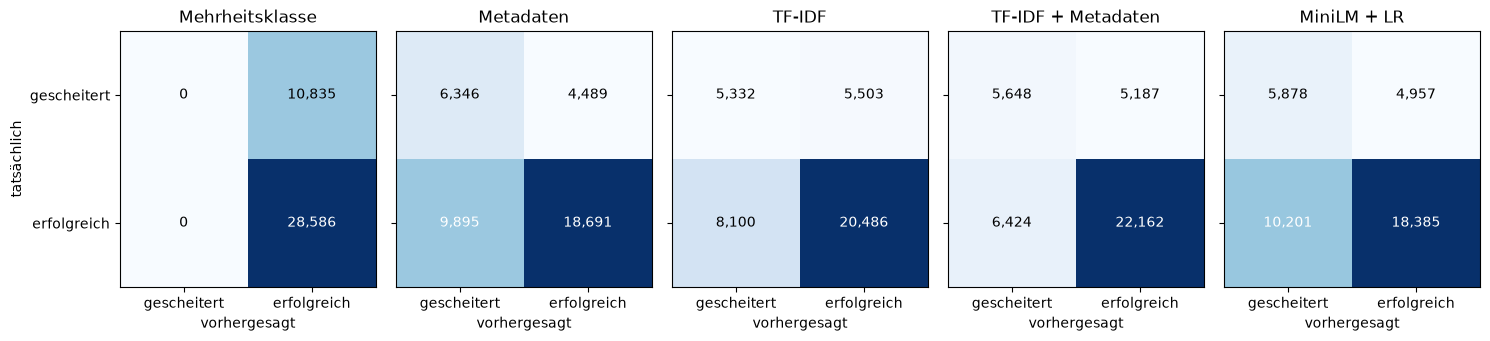

In [15]:
fig, axes = plt.subplots(1, len(preds), figsize=(15, 3.2), sharey=True)
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, p)
    print(f'{name:20s} {cm.ravel()}')  # Zeilenweise, erst gescheitert, dann erfolgreich
    ax.imshow(cm, cmap='Blues')
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f'{v:,}', ha='center', va='center', color='white' if v > cm.max() / 2 else 'black')
    ax.set(title=name, xticks=[0, 1], yticks=[0, 1], xticklabels=LABELS, yticklabels=LABELS,
           xlabel='vorhergesagt')
axes[0].set_ylabel('tatsächlich')
plt.tight_layout(); plt.show()

**Abbildung 2:** Konfusionsmatrizen aller Systeme auf dem Testset 2021 bis 2025. Zeilen zeigen die tatsächliche, Spalten die vorhergesagte Klasse.

Die Matrizen bestätigen dieses Bild. Die Kombination senkt die falschen Warnungen gegenüber dem Metadatenmodell von 9.895 auf 6.424 und erkennt dabei 5.648 der 10.835 gescheiterten Kampagnen.

### 3.8 Zeitliche Stabilität und aussagekräftige Wörter

Für den zweiten Teil der Forschungsfrage berechne ich den Makro-F1 jedes Systems getrennt für jedes Testjahr. Die Tabelle zeigt außerdem die tatsächliche Erfolgsquote und den Anteil der Kampagnen, die das Textmodell als erfolgreich vorhersagt.

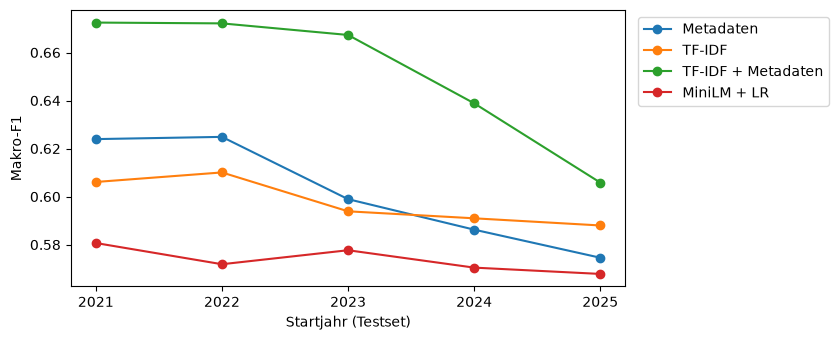

Änderung 2021 bis 2025: {'Metadaten': -0.049, 'TF-IDF': -0.018, 'TF-IDF + Metadaten': -0.067, 'MiniLM + LR': -0.013}


,Metadaten,TF-IDF,TF-IDF + Metadaten,MiniLM + LR,Erfolgsquote,vorhergesagt erfolgreich (TF-IDF)
2021,0.624,0.606,0.672,0.581,0.765,0.646
2022,0.625,0.610,0.672,0.572,0.735,0.643
2023,0.599,0.594,0.667,0.578,0.747,0.658
2024,0.586,0.591,0.639,0.570,0.715,0.656
2025,0.575,0.588,0.606,0.568,0.703,0.675


In [16]:
yr = test['launched_year'].values
systems = ['Metadaten', 'TF-IDF', 'TF-IDF + Metadaten', 'MiniLM + LR']
years_test = sorted(set(yr))
by_year = pd.DataFrame({s: [f1_score(y_test[yr == j], preds[s][yr == j], average='macro') for j in years_test]
                        for s in systems}, index=years_test)
by_year['Erfolgsquote'] = test.groupby('launched_year')['success'].mean()
by_year['vorhergesagt erfolgreich (TF-IDF)'] = pd.Series(preds['TF-IDF']).groupby(yr).mean().values
ax = by_year[systems].plot(marker='o', figsize=(8.5, 3.5), xticks=by_year.index)
ax.set(xlabel='Startjahr (Testset)', ylabel='Makro-F1'); ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()
print('Änderung 2021 bis 2025:', (by_year.loc[2025, systems] - by_year.loc[2021, systems]).round(3).to_dict())
by_year.round(3)

**Abbildung 3:** Makro-F1 je Startjahr im Testset für die 4 gelernten Systeme.

Abbildung 3 zeigt den Kern der Arbeit. Das Metadatenmodell verliert über die Testjahre deutlich. Sein Makro-F1 fällt von 0,624 im Jahr 2021 auf 0,575 im Jahr 2025, also um 0,049. Das Textmodell beginnt niedriger mit 0,606, verliert aber nur 0,018 und endet bei 0,588. 2024 und 2025 liegt der Text allein knapp vor den Metadaten, 2024 ist der Abstand aber verschwindend klein. Die Kombination bleibt in jedem Jahr das beste System, verliert mit 0,067 aber am meisten und endet bei 0,606. MiniLM bleibt fast konstant zwischen 0,568 und 0,581, allerdings auf niedrigem Niveau.

Die Erfolgsquote sinkt im Testzeitraum von 0,765 auf 0,703, während das Textmodell einen wachsenden Anteil von 0,646 bis 0,675 als erfolgreich einstuft. Ein Teil des Rückgangs kann mit dieser Verschiebung zusammenhängen. Ob sich die Vorhersagen des Metadatenmodells ähnlich verschieben, zeigt die Tabelle nicht. Möglich ist auch, dass sich der Zusammenhang zwischen Ziel, Kategorie und Erfolg ändert und ein Textmodell, das sein Gewicht auf viele Wörter verteilt, davon weniger betroffen ist. Geprüft habe ich das nicht.

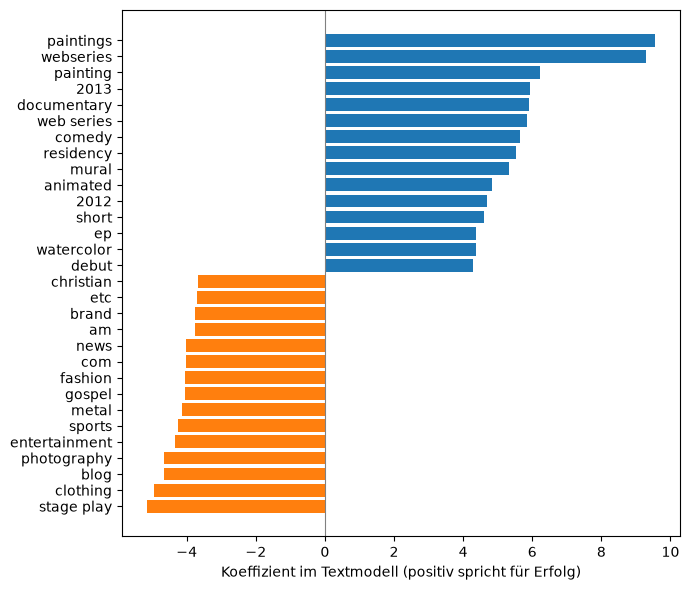

positiv: paintings, webseries, painting, 2013, documentary, web series, comedy, residency, mural, animated, 2012, short, ep, watercolor, debut
negativ: stage play, clothing, blog, photography, entertainment, sports, metal, gospel, fashion, com, news, am, brand, etc, christian
689 Texte in train nennen 2012 oder 2013, Anteil mit Start 2011 bis 2013 0.898, erfolgreich 0.898


In [17]:
coef = pd.Series(text_model.coef_[0], index=tfidf.get_feature_names_out()).sort_values()
top = pd.concat([coef.head(15), coef.tail(15)])
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color=np.where(top.values > 0, 'tab:blue', 'tab:orange'))
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel('Koeffizient im Textmodell (positiv spricht für Erfolg)')
plt.tight_layout(); plt.show()
print('positiv:', ', '.join(coef.tail(15).index[::-1]))
print('negativ:', ', '.join(coef.head(15).index))
has_year = train[train['text'].str.contains(r'\b201[23]\b')]  # Texte, die 2012 oder 2013 nennen
print(f'{len(has_year)} Texte in train nennen 2012 oder 2013, Anteil mit Start 2011 bis 2013 '
      f'{has_year.launched_year.between(2011, 2013).mean():.3f}, erfolgreich {has_year.success.mean():.3f}')

**Abbildung 4:** Je 15 Wörter und Wortpaare mit den größten positiven (blau) und negativen (orange) Koeffizienten im reinen Textmodell.

Die Wörter mit den stärksten Koeffizienten stehen vor allem für Kategorien. Für Erfolg sprechen etwa painting, mural, webseries und documentary aus Kunst und Film, gegen Erfolg clothing, fashion, sports und die Musikrichtungen metal und gospel. Das Textmodell lernt also zu einem guten Teil die Art des Projekts, was zum Gleichstand mit Ziel und Kategorie passt.

Zwei Beobachtungen mahnen zur Vorsicht. Die Jahreszahlen 2012 und 2013 gehören zu den stärksten positiven Merkmalen. Von den 689 Trainingstexten mit einer dieser Zahlen starteten 89,8 % in den Jahren 2011 bis 2013, also in Jahren mit ungewöhnlich hoher Erfolgsquote im Abzug, und ebenso viele waren erfolgreich. Das ist eine Eigenheit der Stichprobe, kein Zusammenhang, den eine Gründerin nutzen könnte. Dieselbe Verzerrung kann auch Wörter begünstigen, die in den frühen Jahren häufig waren. Auch com und am sind eher Spuren des Schreibstils, etwa eine Webadresse oder die Ich-Form, als Ursachen für einen Misserfolg.

### 3.9 Antwort auf die Forschungsfrage

Titel und Kurztext allein sagen den Erfolg der Jahrgänge 2021 bis 2025 mit einem Makro-F1 von 0,595 voraus. Das ist klar besser als die Mehrheitsklasse mit 0,42 und genauso gut wie Ziel und Kategorie. Zusammen mit den Metadaten steigt der Wert auf 0,643. Der Text enthält also zusätzliche Information, die Vorhersage bleibt aber mäßig.

Über die Jahre scheint sich das Textmodell besser zu halten. Es verliert von 2021 bis 2025 nur 0,018, das Metadatenmodell 0,049. Ohne Konfidenzintervalle und bei nur 5 Testjahren ist das eine Tendenz, kein gesicherter Befund. Weil alle gelernten Systeme verlieren, sollte ein eingesetztes Modell regelmäßig mit neuen Jahrgängen nachtrainiert werden.

## 4 Kritische Reflexion und Fazit

### 4.1 Vergleich mit dem Stand der Technik

Die Zahlen aus der Literatur liegen über meinen. Gunduz und Alatas (2024) erreichen mit feinabgestimmtem BERT auf Kurztexten eine Accuracy von 0,745 und F1-Werte von 0,636 für gescheiterte und 0,803 für erfolgreiche Kampagnen. Mein reines Textmodell kommt auf eine Accuracy von 0,655 und F1-Werte von 0,439 und 0,751. Die Accuracy ist kaum vergleichbar, weil meine Modelle wegen der Klassengewichtung bewusst unter der Mehrheitsklasse mit 0,725 bleiben. Der Abstand liegt wohl zum Teil am feinabgestimmten Modell und zum Teil an der zufälligen Aufteilung, bei der das Modell keine Veränderung über die Jahre überstehen muss. Einen Hinweis darauf gibt der Schritt von dev zum Testzeitraum, in dem der Makro-F1 des Textmodells von 0,656 auf 0,595 fällt. Der dev-Wert ist allerdings etwas zu günstig, weil C auf dev gewählt wurde.

Mitra und Gilbert (2014) berichten eine Fehlerrate von nur 2,4 % mit Phrasen und Kontrollvariablen gegenüber 17,03 % mit Kontrollvariablen allein. Sie nutzen aber die vollständige Beschreibung und bewerten innerhalb eines Zeitraums. Die Richtung stimmt mit meinem Ergebnis überein, denn auch bei mir verbessert der Text ein Modell mit Metadaten. Die Größenordnung erreiche ich mit dem kurzen Text bei weitem nicht. Etter et al. (2013) erreichen 4 Stunden nach dem Start eine Accuracy von über 76 %, nutzen dafür aber den Verlauf der Zusagen, der beim Start noch fehlt.

### 4.2 Schwierigkeiten und Grenzen

Die größte Grenze sind die Daten. Der Abzug ist keine Vollerhebung, und die Erfolgsquote der frühen Jahre zeigt, dass er erfolgreiche Kampagnen überrepräsentiert. Alle absoluten Werte gelten deshalb für diesen Abzug und nicht für Kickstarter insgesamt. Die verzerrten Jahre 2009 bis 2013 liegen vollständig in train und prägen dort einzelne Merkmale, wie die Jahreszahlen unter den stärksten Wörtern zeigen. Auch im Testzeitraum ändert sich die Stichprobe, 2024 und 2025 enthalten mit 10.361 und 12.637 Kampagnen mindestens doppelt so viele wie 2021 mit 4.961. Die Sprache habe ich nur über das Land gefiltert, einzelne Texte in anderen Sprachen sind also möglich.

Beim vortrainierten Modell musste ich Abstriche machen. Ohne Feinabstimmung und mit nur 15.000 Trainingskampagnen ist sein Ergebnis eher eine Untergrenze für vortrainierte Modelle. Beides war eine bewusste Entscheidung für einen schnellen Lauf auf der CPU, eine Feinabstimmung auf allen Daten wäre auf den Rechenservern der FH Südwestfalen der nächste Schritt.

Außerdem nutze ich nur Titel und Kurztext. Beschreibung, Bilder, Video und Belohnungsstufen fehlen, obwohl sie beim Start ebenfalls vorliegen. Die Klassengewichtung verschiebt die Entscheidungsschwelle, und weil die Erfolgsquote zwischen den Jahren schwankt, hängen Precision und Recall auch von dieser Wahl ab. Schließlich habe ich keine Konfidenzintervalle berechnet. Kleine Unterschiede zwischen einzelnen Testjahren sollten daher nicht überinterpretiert werden.

### 4.3 Was ich gelernt habe und Fazit

Gelernt habe ich vor allem, dass die Art der Aufteilung bestimmt, welche Frage eine Evaluation beantwortet. Eine zufällige Aufteilung hätte die Veränderung über die Jahre verdeckt. Überrascht hat mich, wie sehr ein einfaches TF-IDF-Modell die Kategorie nachbildet und sogar Jahreszahlen als Signal nutzt. Außerdem habe ich gesehen, dass ein vortrainiertes Modell ohne Feinabstimmung und mit knapper Rechenzeit nicht automatisch besser ist als ein lineares Modell auf Wortmerkmalen.

Der Kurztext ist beim Start ein brauchbares, aber schwaches Signal, das Ziel und Kategorie ergänzt. Für eine verlässliche Einzelprognose reicht keines der Modelle, und Ursachen für Erfolg lassen sich aus den Koeffizienten nicht ablesen. Als nächste Schritte würde ich ein feinabgestimmtes Sprachmodell auf allen Trainingsdaten, die vollständige Beschreibung und ein jährliches Nachtrainieren prüfen.

## Literaturverzeichnis

Etter, V., Grossglauser, M., & Thiran, P. (2013). Launch hard or go home! Predicting the success of Kickstarter campaigns. In *Proceedings of the First ACM Conference on Online Social Networks (COSN '13)*. ACM. https://doi.org/10.1145/2512938.2512957

Greenberg, M. D., Pardo, B., Hariharan, K., & Gerber, E. (2013). Crowdfunding support tools: Predicting success & failure. In *CHI '13 Extended Abstracts on Human Factors in Computing Systems* (S. 1815-1820). ACM. https://doi.org/10.1145/2468356.2468682

Gunduz, H., & Alatas, B. (2024). Comparative analysis of BERT and FastText representations on crowdfunding campaign success prediction. *PeerJ Computer Science, 10*, e2316. https://doi.org/10.7717/peerj-cs.2316

Mitra, T., & Gilbert, E. (2014). The language that gets people to give: Phrases that predict success on Kickstarter. In *Proceedings of the 17th ACM Conference on Computer Supported Cooperative Work & Social Computing (CSCW '14)*. ACM. https://doi.org/10.1145/2531602.2531656

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. In *Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing and the 9th International Joint Conference on Natural Language Processing (EMNLP-IJCNLP)* (S. 3982-3992). Association for Computational Linguistics.

Wang, W., Wei, F., Dong, L., Bao, H., Yang, N., & Zhou, M. (2020). MiniLM: Deep self-attention distillation for task-agnostic compression of pre-trained transformers. In *Advances in Neural Information Processing Systems 33 (NeurIPS 2020)*.

webrobots.io. (2026). *Kickstarter datasets, Abzug vom 10.09.2026* [Datensatz]. https://webrobots.io/kickstarter-datasets/

## Erklärung

Ich erkläre hiermit, dass ich die vorliegende Arbeit selbstständig verfasst und dabei keine anderen als die angegebenen Hilfsmittel benutzt habe. Sämtliche Stellen der Arbeit, die im Wortlaut oder dem Sinn nach Werken anderer Autoren entnommen sind, habe ich als solche kenntlich gemacht. Die Arbeit wurde bisher weder gesamt noch in Teilen einer anderen Prüfungsbehörde vorgelegt und auch noch nicht veröffentlicht.

28.09.2026

Yurii Dobrytsia